<a href="https://colab.research.google.com/github/phaniidk/part-3-nlp-sequence-modeling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [3]:
df = pd.read_csv("customer_support_text_classification.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

First 5 Rows:
  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  

Dataset Shape:
(1500, 6)

Columns:
Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')


In [4]:
text_column = df.columns[0]
label_column = df.columns[1]

In [5]:
print("\nNumber of Records:")
print(len(df))

print("\nTarget Classes:")
print(df[label_column].unique())

print("\nClass Distribution:")
print(df[label_column].value_counts())


Number of Records:
1500

Target Classes:
['chat' 'phone' 'email' 'social' 'app']

Class Distribution:
channel
email     326
social    314
phone     296
chat      290
app       274
Name: count, dtype: int64


In [6]:
print("\nSample Texts:\n")

for i in range(5):
    print(df[text_column][i])
    print()


Sample Texts:

TKT00001

TKT00002

TKT00003

TKT00004

TKT00005



In [7]:
df['text_length'] = df[text_column].apply(len)

print("\nAverage Text Length:")
print(df['text_length'].mean())


Average Text Length:
8.0


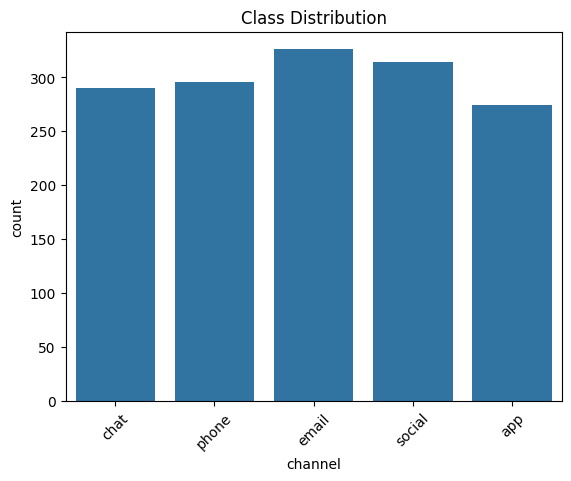

In [8]:
sns.countplot(x=label_column, data=df)

plt.title("Class Distribution")

plt.xticks(rotation=45)

plt.show()

In [9]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)

    return text

df[text_column] = df[text_column].astype(str)

df[text_column] = df[text_column].apply(clean_text)


In [10]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df[text_column]).toarray()

In [11]:
encoder = LabelEncoder()

y = encoder.fit_transform(df[label_column])

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:

baseline_model = Sequential()

baseline_model.add(Dense(
    128,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

baseline_model.add(Dense(64, activation='relu'))

baseline_model.add(Dense(
    len(np.unique(y)),
    activation='softmax'
))

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
history = baseline_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1969 - loss: 1.6094 - val_accuracy: 0.1833 - val_loss: 1.6110
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2979 - loss: 1.5795 - val_accuracy: 0.1875 - val_loss: 1.6125
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3333 - loss: 1.5267 - val_accuracy: 0.1875 - val_loss: 1.6133
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7156 - loss: 1.3885 - val_accuracy: 0.2000 - val_loss: 1.6196
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9521 - loss: 1.0618 - val_accuracy: 0.2167 - val_loss: 1.6280
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.5649 - val_accuracy: 0.2083 - val_loss: 1.6446
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.1856 - val_accuracy: 0.2333 - val_loss: 1.6480
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0596 - val_accuracy: 0.2250 - val_

In [15]:
loss, accuracy = baseline_model.evaluate(X_test, y_test)

print("\nTest Accuracy:")
print(accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2000 - loss: 1.7220 

Test Accuracy:
0.20000000298023224


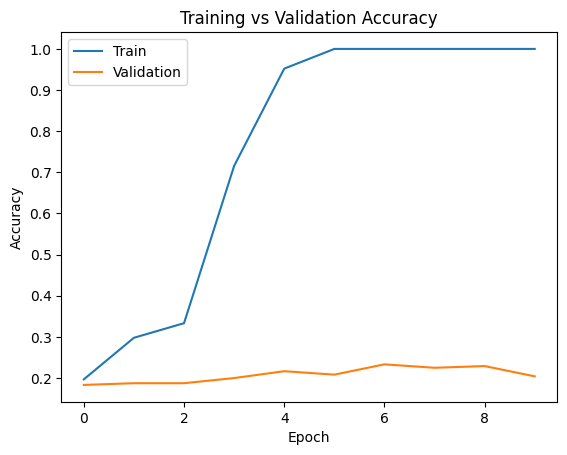

In [16]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.savefig("model_evaluation.png")

plt.show()

In [17]:
y_pred = baseline_model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


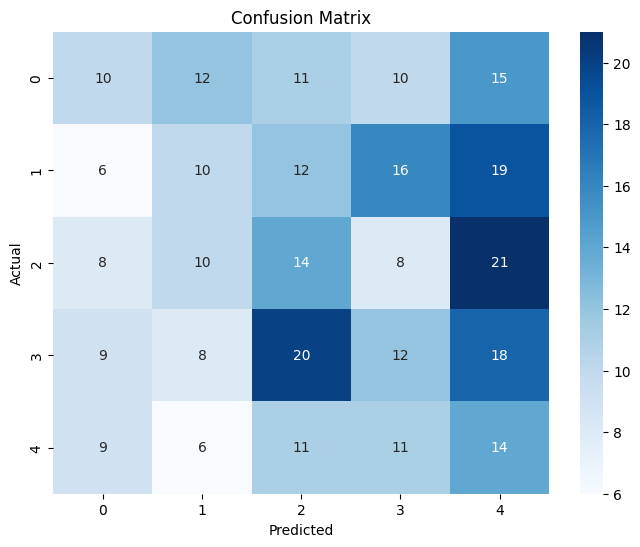

In [18]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


In [19]:
print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_classes))


Classification Report:

              precision    recall  f1-score   support

           0       0.24      0.17      0.20        58
           1       0.22      0.16      0.18        63
           2       0.21      0.23      0.22        61
           3       0.21      0.18      0.19        67
           4       0.16      0.27      0.20        51

    accuracy                           0.20       300
   macro avg       0.21      0.20      0.20       300
weighted avg       0.21      0.20      0.20       300



In [20]:
sample_file = open("sample_predictions.txt", "w")

for i in range(5):

    original_text = df[text_column].iloc[i]

    predicted_label = encoder.inverse_transform(
        [y_pred_classes[i]]
    )[0]

    sample_file.write(
        f"Text: {original_text}\n"
    )

    sample_file.write(
        f"Predicted Label: {predicted_label}\n\n"
    )

sample_file.close()

In [21]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df[text_column])

sequences = tokenizer.texts_to_sequences(
    df[text_column]
)

X_seq = pad_sequences(
    sequences,
    maxlen=100
)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
lstm_model = Sequential()

lstm_model.add(
    Embedding(
        input_dim=5000,
        output_dim=64,
        input_length=100
    )
)

lstm_model.add(LSTM(64))

lstm_model.add(
    Dense(
        len(np.unique(y)),
        activation='softmax'
    )
)

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [23]:
lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

print("\nPROJECT COMPLETED SUCCESSFULLY")

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.2240 - loss: 1.6102 - val_accuracy: 0.1792 - val_loss: 1.6115
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.2438 - loss: 1.5996 - val_accuracy: 0.1792 - val_loss: 1.6117
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.2313 - loss: 1.5854 - val_accuracy: 0.1792 - val_loss: 1.6156
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.4208 - loss: 1.5452 - val_accuracy: 0.1792 - val_loss: 1.6152
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.6427 - loss: 1.3594 - val_accuracy: 0.1833 - val_loss: 1.6882

PROJECT COMPLETED SUCCESSFULLY
